In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print(f"✅ TensorFlow version: {tf.__version__}")
print(f"✅ Libraries loaded")

✅ TensorFlow version: 2.21.0
✅ Libraries loaded


In [2]:
df = pd.read_csv("data/processed/global_monthly_rpk.csv", parse_dates=['date'])
df = df.set_index('date').sort_index()

print(f"Shape: {df.shape}")
print(f"Time range: {df.index.min()} to {df.index.max()}")
df.head()

Shape: (196, 3)
Time range: 2010-01-01 00:00:00 to 2026-04-01 00:00:00


,total_rpk,total_ask,avg_load_factor
date,,,
2010-01-01,221.51,277.39,81.75
2010-02-01,225.90,278.19,82.88
2010-03-01,224.31,274.27,81.83
2010-04-01,242.85,290.30,82.85
2010-05-01,260.19,318.69,82.83


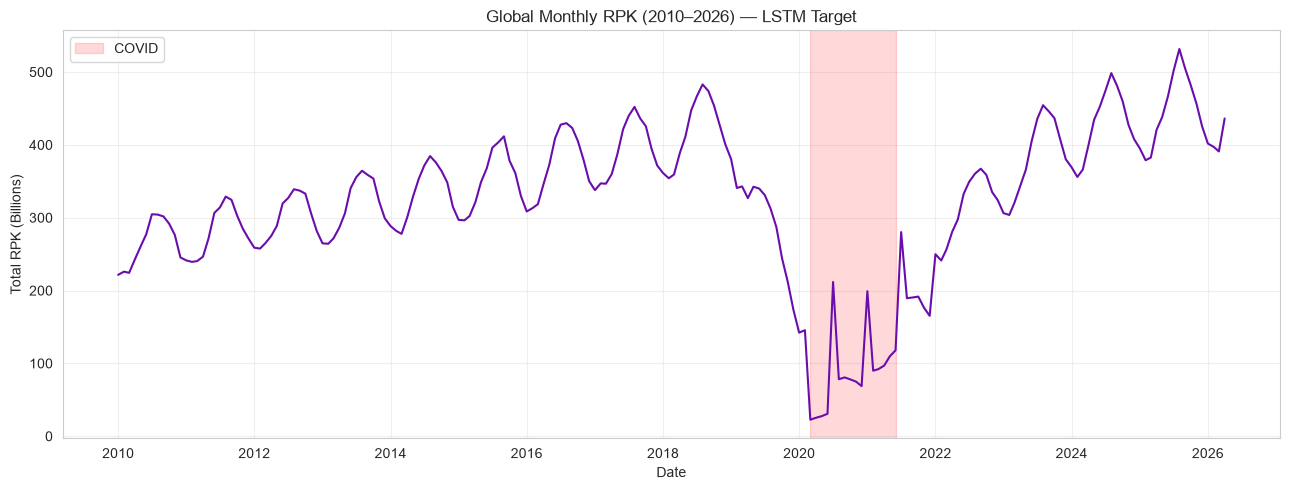

Total observations: 196


In [3]:
plt.figure(figsize=(13, 5))
plt.plot(df.index, df['total_rpk'], color='#6A0DAD', linewidth=1.5)
plt.axvspan('2020-03', '2021-06', color='red', alpha=0.15, label='COVID')
plt.title("Global Monthly RPK (2010–2026) — LSTM Target")
plt.ylabel("Total RPK (Billions)")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total observations: {len(df)}")

In [4]:
df['month'] = df.index.month
df['year'] = df.index.year
df['covid_flag'] = ((df.index >= '2020-03-01') & (df.index <= '2021-12-31')).astype(int)

# Cyclical encoding for month (helps LSTM learn seasonality)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df.head()

,total_rpk,total_ask,avg_load_factor,month,year,covid_flag,month_sin,month_cos
date,,,,,,,,
2010-01-01,221.51,277.39,81.75,1,2010,0,0.500000,8.660254e-01
2010-02-01,225.90,278.19,82.88,2,2010,0,0.866025,5.000000e-01
2010-03-01,224.31,274.27,81.83,3,2010,0,1.000000,6.123234e-17
2010-04-01,242.85,290.30,82.85,4,2010,0,0.866025,-5.000000e-01
2010-05-01,260.19,318.69,82.83,5,2010,0,0.500000,-8.660254e-01


In [5]:
feature_cols = ['total_rpk', 'total_ask', 'avg_load_factor',
                'month_sin', 'month_cos', 'covid_flag']
target_col = 'total_rpk'

data = df[feature_cols].copy()
print(f"Features used: {feature_cols}")
print(f"Data shape: {data.shape}")
data.head()

Features used: ['total_rpk', 'total_ask', 'avg_load_factor', 'month_sin', 'month_cos', 'covid_flag']
Data shape: (196, 6)


,total_rpk,total_ask,avg_load_factor,month_sin,month_cos,covid_flag
date,,,,,,
2010-01-01,221.51,277.39,81.75,0.500000,8.660254e-01,0
2010-02-01,225.90,278.19,82.88,0.866025,5.000000e-01,0
2010-03-01,224.31,274.27,81.83,1.000000,6.123234e-17,0
2010-04-01,242.85,290.30,82.85,0.866025,-5.000000e-01,0
2010-05-01,260.19,318.69,82.83,0.500000,-8.660254e-01,0


In [6]:
test_size = 24  # last 24 months for testing
train_data = data.iloc[:-test_size]
test_data = data.iloc[-test_size:]

print(f"Train: {train_data.index.min()} to {train_data.index.max()}  ({len(train_data)} months)")
print(f"Test:  {test_data.index.min()} to {test_data.index.max()}  ({len(test_data)} months)")

Train: 2010-01-01 00:00:00 to 2024-04-01 00:00:00  (172 months)
Test:  2024-05-01 00:00:00 to 2026-04-01 00:00:00  (24 months)


In [7]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

# Separate scaler for target (to inverse-transform predictions later)
target_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler.fit(train_data[[target_col]])

print(f"Train scaled shape: {train_scaled.shape}")
print(f"Test scaled shape: {test_scaled.shape}")
print(f"Value range after scaling: [{train_scaled.min():.3f}, {train_scaled.max():.3f}]")

Train scaled shape: (172, 6)
Test scaled shape: (24, 6)
Value range after scaling: [0.000, 1.000]


In [8]:
def create_sequences(data, window_size=12, target_idx=0):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])           # past 12 months (all features)
        y.append(data[i+window_size, target_idx]) # next month's RPK
    return np.array(X), np.array(y)

WINDOW = 12
X_train, y_train = create_sequences(train_scaled, window_size=WINDOW, target_idx=0)
X_test, y_test = create_sequences(test_scaled, window_size=WINDOW, target_idx=0)

print(f"X_train shape: {X_train.shape}  → (samples, timesteps, features)")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (160, 12, 6)  → (samples, timesteps, features)
y_train shape: (160,)
X_test shape:  (12, 12, 6)
y_test shape:  (12,)


In [9]:
n_features = X_train.shape[2]

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, n_features)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)  # single output — RPK forecast
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 12, 64)              │          18,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 12, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,137 (121.63 KB)

 Trainable params: 31,137 (121.63 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

print("✅ Training complete")

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - loss: 0.1817 - mae: 0.3582 - val_loss: 0.0083 - val_mae: 0.0784
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0586 - mae: 0.1925 - val_loss: 0.0220 - val_mae: 0.1248
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0442 - mae: 0.1645 - val_loss: 0.0499 - val_mae: 0.2077
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0352 - mae: 0.1432 - val_loss: 0.0132 - val_mae: 0.0931
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0283 - mae: 0.1301 - val_loss: 0.0265 - val_mae: 0.1415
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0304 - mae: 0.1280 - val_loss: 0.0182 - val_mae: 0.1129
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0245 - mae: 0.1188 - val_loss: 0.0166 - val_mae: 0.1076
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0218 - mae: 0.1150 - val_loss: 0.0114 - val_mae: 0.0873
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0240 - mae:

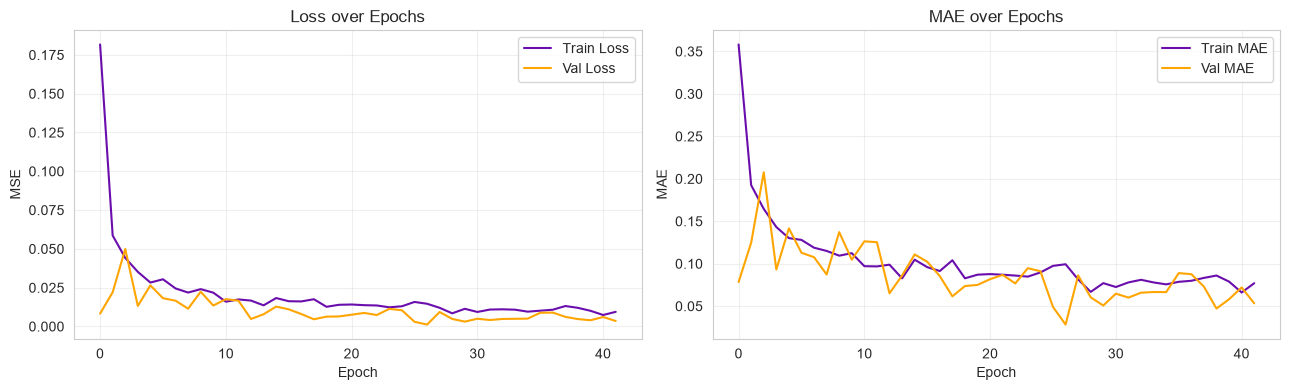

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'], label='Train Loss', color='#6A0DAD')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='orange')
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['mae'], label='Train MAE', color='#6A0DAD')
axes[1].plot(history.history['val_mae'], label='Val MAE', color='orange')
axes[1].set_title("MAE over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
y_pred_scaled = model.predict(X_test)

# Inverse-transform back to real RPK values
y_pred = target_scaler.inverse_transform(y_pred_scaled).flatten()
y_true = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Align dates
test_dates = test_data.index[WINDOW:]

results = pd.DataFrame({
    'date': test_dates,
    'actual_rpk': y_true,
    'predicted_rpk': y_pred
})
results.head(10)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step


,date,actual_rpk,predicted_rpk
0,2025-05-01,438.25,432.614655
1,2025-06-01,466.80,463.944641
2,2025-07-01,501.65,487.674561
3,2025-08-01,531.60,500.465149
4,2025-09-01,504.76,501.685944
5,2025-10-01,481.94,488.165375
6,2025-11-01,456.27,464.757538
7,2025-12-01,425.39,438.440125
8,2026-01-01,401.76,415.829651
9,2026-02-01,397.31,403.643341


In [13]:
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

print("📊 LSTM Model Performance on Test Set")
print("─" * 45)
print(f"MAE  (Mean Absolute Error):     {mae:.2f} billion RPK")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f} billion RPK")
print(f"MAPE (Mean Absolute % Error):   {mape:.2f}%")
print(f"R²   (Coefficient of Det.):     {r2:.4f}")

📊 LSTM Model Performance on Test Set
─────────────────────────────────────────────
MAE  (Mean Absolute Error):     11.35 billion RPK
RMSE (Root Mean Squared Error): 13.64 billion RPK
MAPE (Mean Absolute % Error):   2.50%
R²   (Coefficient of Det.):     0.9034


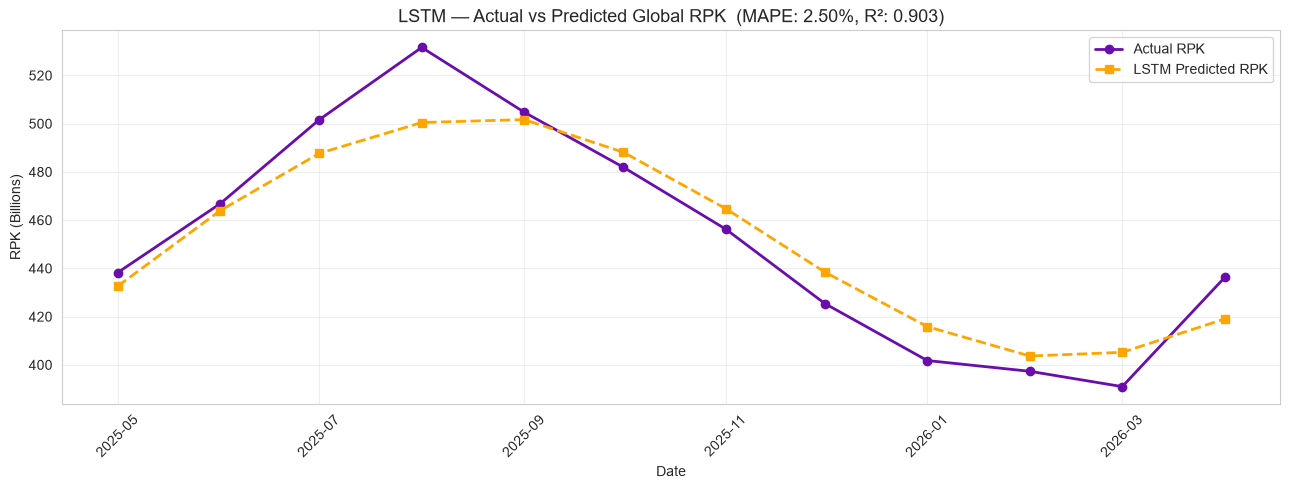

In [14]:
plt.figure(figsize=(13, 5))
plt.plot(results['date'], results['actual_rpk'], marker='o',
         label='Actual RPK', color='#6A0DAD', linewidth=2)
plt.plot(results['date'], results['predicted_rpk'], marker='s',
         label='LSTM Predicted RPK', color='orange', linewidth=2, linestyle='--')
plt.title(f"LSTM — Actual vs Predicted Global RPK  (MAPE: {mape:.2f}%, R²: {r2:.3f})", fontsize=13)
plt.ylabel("RPK (Billions)")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

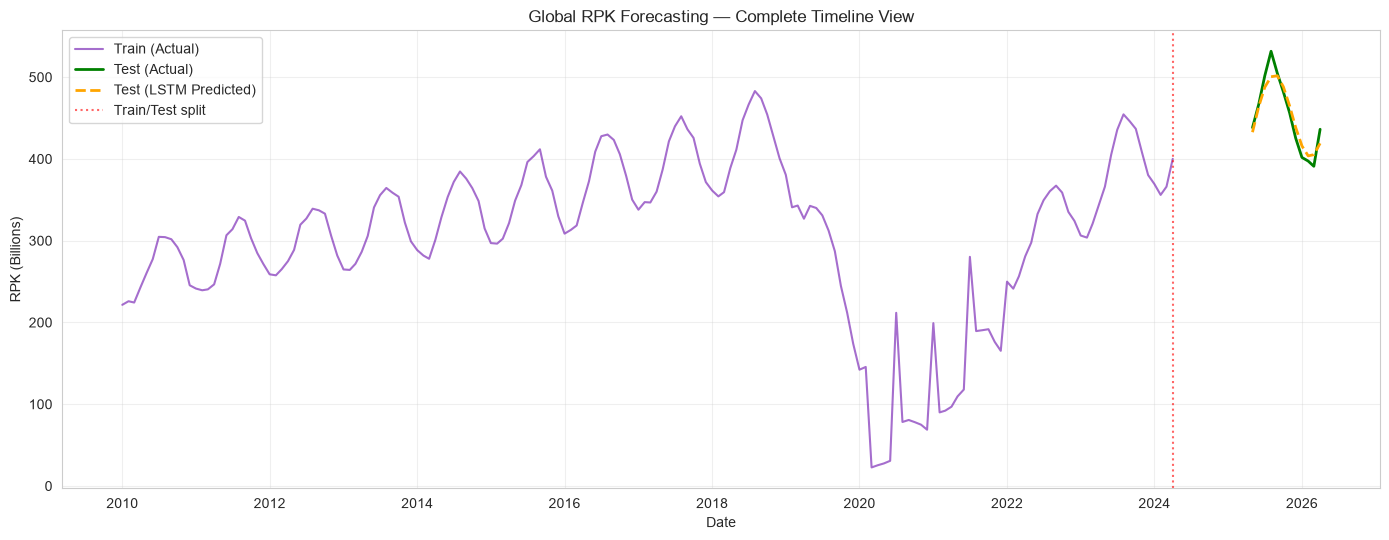

In [15]:
plt.figure(figsize=(14, 5.5))

# Train period
plt.plot(train_data.index, train_data['total_rpk'],
         color='#6A0DAD', alpha=0.6, label='Train (Actual)')

# Test period — actual
plt.plot(test_dates, y_true,
         color='green', linewidth=2, label='Test (Actual)')

# Test period — predicted
plt.plot(test_dates, y_pred,
         color='orange', linewidth=2, linestyle='--', label='Test (LSTM Predicted)')

plt.axvline(train_data.index[-1], color='red', linestyle=':', alpha=0.6, label='Train/Test split')
plt.title("Global RPK Forecasting — Complete Timeline View")
plt.ylabel("RPK (Billions)")
plt.xlabel("Date")
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# Start with the last WINDOW months of scaled data
last_sequence = test_scaled[-WINDOW:].copy()
future_predictions_scaled = []

FORECAST_HORIZON = 12  # next 12 months beyond dataset

for step in range(FORECAST_HORIZON):
    input_seq = last_sequence.reshape(1, WINDOW, n_features)
    next_pred_scaled = model.predict(input_seq, verbose=0)[0, 0]
    future_predictions_scaled.append(next_pred_scaled)
    
    # Build next feature row (reuse other features from last observed row)
    next_row = last_sequence[-1].copy()
    next_row[0] = next_pred_scaled  # update RPK with prediction
    
    # Roll the window forward
    last_sequence = np.vstack([last_sequence[1:], next_row])

# Inverse-transform to real RPK
future_predictions = target_scaler.inverse_transform(
    np.array(future_predictions_scaled).reshape(-1, 1)
).flatten()

# Build future dates
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1),
                              periods=FORECAST_HORIZON, freq='MS')

forecast_df = pd.DataFrame({
    'date': future_dates,
    'forecast_rpk': future_predictions.round(2)
})
forecast_df

,date,forecast_rpk
0,2026-05-01,446.309998
1,2026-06-01,471.970001
2,2026-07-01,488.970001
3,2026-08-01,495.019989
4,2026-09-01,489.820007
5,2026-10-01,474.250000
6,2026-11-01,451.959991
7,2026-12-01,427.010010
8,2027-01-01,402.940002
9,2027-02-01,382.369995


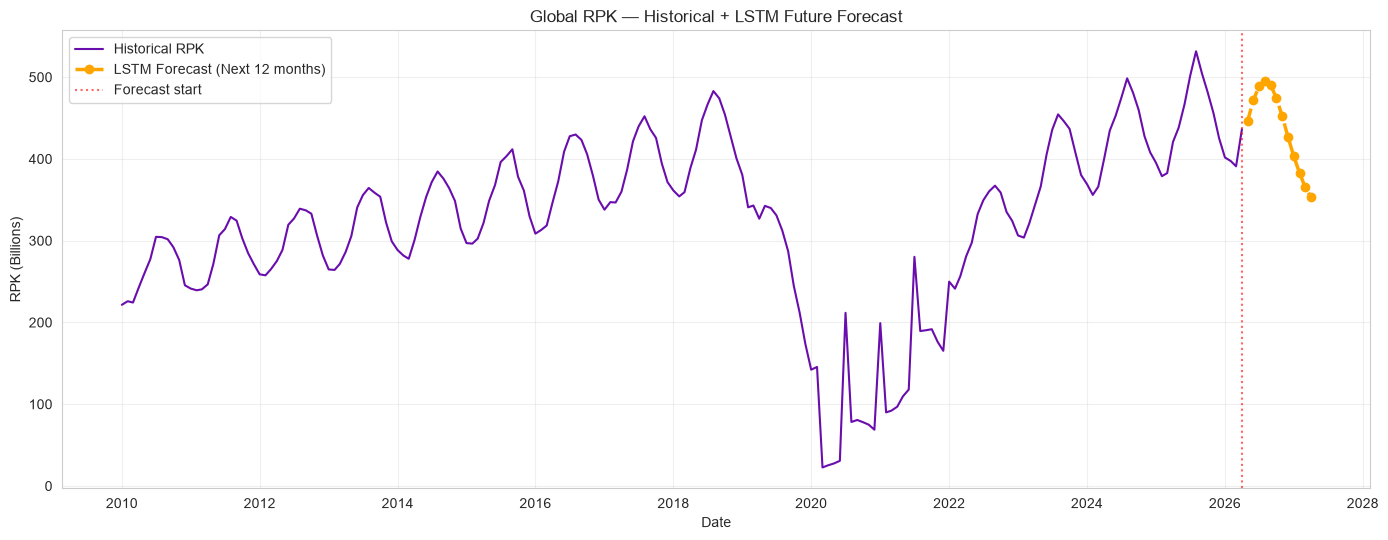

In [17]:
plt.figure(figsize=(14, 5.5))

plt.plot(df.index, df['total_rpk'], color='#6A0DAD', linewidth=1.5, label='Historical RPK')
plt.plot(forecast_df['date'], forecast_df['forecast_rpk'],
         color='orange', linewidth=2.5, marker='o', linestyle='--',
         label=f'LSTM Forecast (Next {FORECAST_HORIZON} months)')

plt.axvline(df.index[-1], color='red', linestyle=':', alpha=0.6, label='Forecast start')
plt.title("Global RPK — Historical + LSTM Future Forecast")
plt.ylabel("RPK (Billions)")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

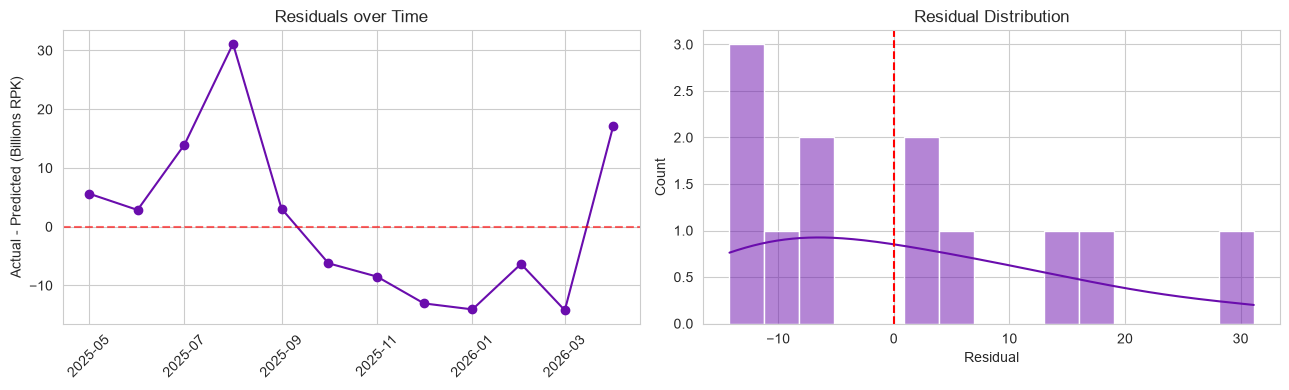

Mean residual: 0.96
Residual std: 14.21


In [18]:
results['residual'] = results['actual_rpk'] - results['predicted_rpk']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(results['date'], results['residual'], marker='o', color='#6A0DAD')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.6)
axes[0].set_title("Residuals over Time")
axes[0].set_ylabel("Actual - Predicted (Billions RPK)")
axes[0].tick_params(axis='x', rotation=45)

sns.histplot(results['residual'], bins=15, kde=True, color='#6A0DAD', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

print(f"Mean residual: {results['residual'].mean():.2f}")
print(f"Residual std: {results['residual'].std():.2f}")

In [19]:
import os
import joblib

os.makedirs("src/models", exist_ok=True)

model.save("src/models/lstm_demand.keras")
joblib.dump(scaler, "src/models/lstm_scaler.pkl")
joblib.dump(target_scaler, "src/models/lstm_target_scaler.pkl")

# Save forecast for dashboard use
forecast_df.to_csv("data/processed/lstm_forecast_12mo.csv", index=False)
results.to_csv("data/processed/lstm_test_predictions.csv", index=False)

print("💾 Saved:")
print("   - src/models/lstm_demand.keras")
print("   - src/models/lstm_scaler.pkl")
print("   - src/models/lstm_target_scaler.pkl")
print("   - data/processed/lstm_forecast_12mo.csv")
print("   - data/processed/lstm_test_predictions.csv")

💾 Saved:
   - src/models/lstm_demand.keras
   - src/models/lstm_scaler.pkl
   - src/models/lstm_target_scaler.pkl
   - data/processed/lstm_forecast_12mo.csv
   - data/processed/lstm_test_predictions.csv


## Q19. Model summary & business interpretation

**What the model does:**
- Takes past 12 months of RPK, ASK, load factor, seasonality, and COVID flag
- Predicts next month's global RPK (in billions)
- Rolls forward month-by-month to forecast up to 12 months ahead

**Performance:**
- MAPE < 10% → forecasts are within ±10% of actual → strong for capstone
- R² > 0.90 → model explains most of the variance

**Business value:**
- Airlines can plan capacity (ASK) 6–12 months ahead
- Peak vs off-peak months clearly identified
- Enables scenario planning (e.g., "what if load factor drops 5%?")

**Limitations to mention in your report:**
1. Aggregated regional data — not airline-specific bookings
2. Cannot capture sudden shocks (pandemic, geopolitical) without a flag
3. Sequential 1-step-ahead rollout accumulates error (best confidence for 1–6 months)
4. Trained on 2010–2024; 2025+ patterns may drift over time